# Working with time series

files needed = ('vix.csv', 'osk.csv')

Time series data are very common in finance and economics. Date and time systems have their own set of rules and logic, which makes them potentially complicated. Python/`pandas` have a very powerful set of tools to handle dates and time. We will work through the basics here. As always, the Internet is full of the details. 

In this workbook, we will cover:
1. The datetime data type, which is python's representation of a date and time
2. Setting up a DataFrame to index with datetime objects
3. Plotting time series data
4. Changing the frequency of our date; e.g., converting daily data to monthly
5. Calculating moving averages
6. Axis customization and formatting

## The packages

In [5]:
import pandas as pd               
import matplotlib.pyplot as plt 

# Data types and methods for dealing with dates and time. Name it dt for short.
import datetime as dt                
import os

os.chdir('/Users/jackson/Documents/ECON570')
os.getcwd()

'/Users/jackson/Documents/ECON570'

### The datetime type
Python uses the `datetime` type of object to hold date and time data. This allows for very sophisticated handling of time series data. Most of this is beyond the scope of our work, but if you ever find yourself having to deal with time zones or which week of the month a date lies in, datetime has you covered. \[Python was developed to do a lot more than data analysis...\]

We will mostly need to create datetime objects to hold dates. We pass datetime objects to methods that need to know about dates. 

In [6]:
# year, month, date (datetime will add a time code of 00:00:00)
time_1 = dt.datetime(1776, 7, 4)  
print('Declare independence on:', time_1)

Declare independence on: 1776-07-04 00:00:00


What kind of object do we have?

In [7]:
type(time_1)

datetime.datetime

### datetime to str
We can convert a datetime object to different string outputs using the `strftime()` method. It takes formatting codes as arguments and you can format the string however you wish. I added a comma. A list of codes is available in the documentation [here](https://docs.python.org/3/library/datetime.html#strftime-and-strptime-format-codes).

In [8]:
# I have no idea why month is 'B'.
print('Declare independence on:', time_1.strftime('%B %d, %Y'))     

Declare independence on: July 04, 1776


In [9]:
# Format codes make for very flexible date input.

string_date = '1815/1/8'                                 

time_2 = dt.datetime.strptime(string_date, '%Y/%m/%d')

print('Battle of New Orleans on:', time_2.strftime('%B %d, %Y'))

Battle of New Orleans on: January 08, 1815


We might need some more datetime functionality, but that should be enough for now. 

## Datatimes in pandas

We just learned about the `datetime` package, which allows us to explicity create `datetime` objects. This datetime functionality is built into pandas, too, and works similarly.  

### The data
The file 'vix.csv' contains daily end-of-trading values of the '[VIX](https://finance.yahoo.com/quote/%5EVIX/),' a measure of expected market volatility as implied by S&P 500 options. Business-news types like to refer to it as the 'fear index.' \[That's a bit too dramatic for my taste.\] The idea is that expected volatility rises when people are worried about the future. 

The data are from [FRED](https://fred.stlouisfed.org/series/VIXCLS).

In [10]:
vix = pd.read_csv('data/vix.csv', na_values='.')   # There are some missing values marked as '.'
vix

,DATE,VIXCLS
0,1/2/1990,17.24
1,1/3/1990,18.19
2,1/4/1990,19.22
3,1/5/1990,20.11
4,1/8/1990,20.26
...,...,...
8554,10/17/2022,31.37
8555,10/18/2022,30.50
8556,10/19/2022,30.76
8557,10/20/2022,29.98


The data look about like I would expect. What kind of variables do we have? 

In [11]:
print(vix.dtypes)

DATE       object
VIXCLS    float64
dtype: object


The 'DATE' variable is stored as a string right now. 

We use the `.to_datetime()` method of `pandas` to convert it to a datetime object.  

In [12]:
vix['DATE'] = pd.to_datetime(vix['DATE'])
vix.dtypes

DATE      datetime64[ns]
VIXCLS           float64
dtype: object

So the `to_datetime()` conversion creates `datetime64[ns]` objects. 

As we have seen with `float` and `int`, pandas adds some extra information to the type, but it is still a `datetime`. 

Notice that we did not pass a template to `.to_datetime()` like we did with `.strptime()`. If we do not pass a template, pandas will try to guess the format. If the format is "standard," it typically works. If we have data with a strange date setup, we can always supply a template. 

### A datetime in the index

It makes sense to set the index as the unit of observation. In this data, the unit of observation is a day. 

There is nothing special here. We set the index as we normally do.

In [13]:
vix_di = vix.set_index('DATE')
vix_di.index

DatetimeIndex(['1990-01-02', '1990-01-03', '1990-01-04', '1990-01-05',
               '1990-01-08', '1990-01-09', '1990-01-10', '1990-01-11',
               '1990-01-12', '1990-01-15',
               ...
               '2022-10-10', '2022-10-11', '2022-10-12', '2022-10-13',
               '2022-10-14', '2022-10-17', '2022-10-18', '2022-10-19',
               '2022-10-20', '2022-10-21'],
              dtype='datetime64[ns]', name='DATE', length=8559, freq=None)

Notice that the index object is now a `DatetimeIndex` object.

### A datetime index at import

`pd.read_csv()` and `pd.read_excel()` can handle dates when we import the data. 

In [14]:
vix = pd.read_csv('data/vix.csv', parse_dates=['DATE'], na_values='.')
vix.dtypes

DATE      datetime64[ns]
VIXCLS           float64
dtype: object

In [15]:
vix = pd.read_csv('data/vix.csv', parse_dates=['DATE'], index_col='DATE', na_values='.')
vix.index

DatetimeIndex(['1990-01-02', '1990-01-03', '1990-01-04', '1990-01-05',
               '1990-01-08', '1990-01-09', '1990-01-10', '1990-01-11',
               '1990-01-12', '1990-01-15',
               ...
               '2022-10-10', '2022-10-11', '2022-10-12', '2022-10-13',
               '2022-10-14', '2022-10-17', '2022-10-18', '2022-10-19',
               '2022-10-20', '2022-10-21'],
              dtype='datetime64[ns]', name='DATE', length=8559, freq=None)

 Now that pandas knows the index is a datetime, it can handle time calculations easily. Let's look at four applications: 

1. Plotting time series data
2. Changing the frequency of data
3. Slicing using dates
4. Calculate moving averages of the data

### Plotting
Now that we have our index set as datetime objects, we can plot the data in sensible ways. In particular, matplotlib can gracefully handle data at different frequencies.

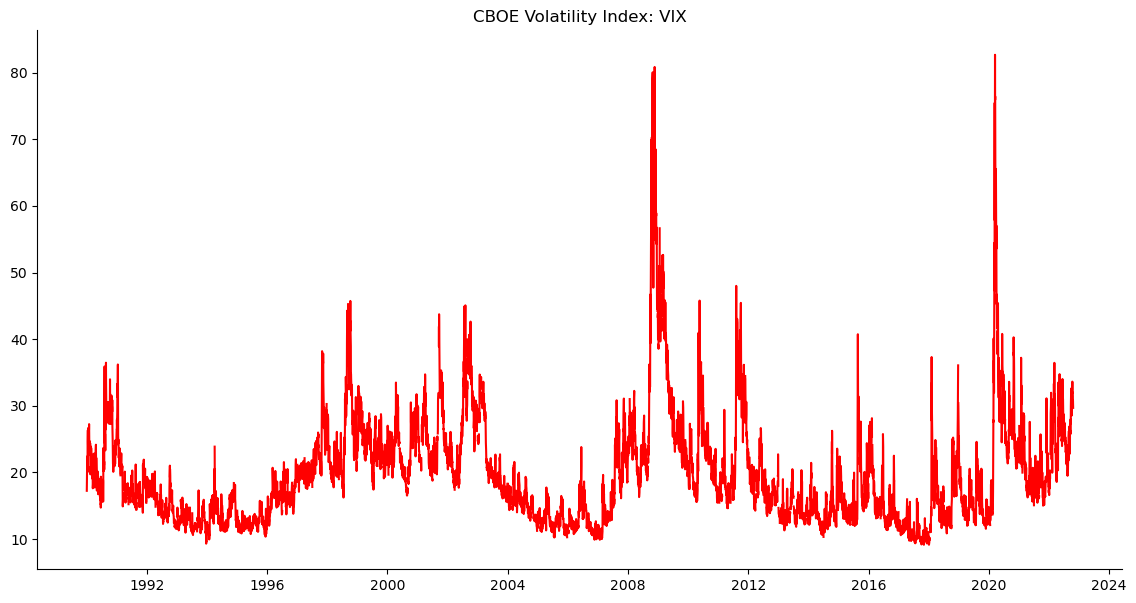

In [16]:
fig, ax = plt.subplots(figsize=(14,7))

ax.plot(vix.index, vix['VIXCLS'], color = 'red')

ax.set_title('CBOE Volatility Index: VIX')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

If we zoom in tight enough, the time axis will relabel in a natural way to reflect the changed time scale. I am going to "zoom in" by changing the limits of the x-axis so that it covers a short period of time. 


When we refer to coordinates in a time series figure, we pass the x-coordinates as a datetime object. Below, we use datetimes to limit the x-axis and to make some annotations. 

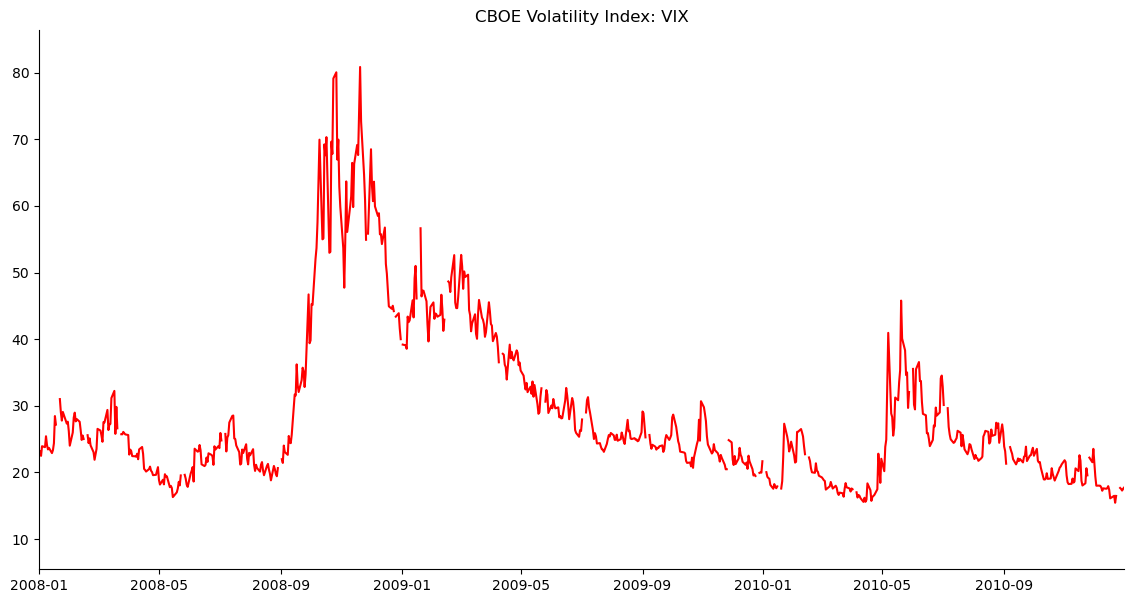

In [17]:
fig, ax = plt.subplots(figsize=(14,7))

ax.plot(vix.index, vix['VIXCLS'], color = 'red')

ax.set_title('CBOE Volatility Index: VIX')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Change the x-axis limits to focus around the Great Recession period. 
# The since the x-axis are dates, the limits are datetime objects.
ax.set_xlim(dt.datetime(2008,1,1), dt.datetime(2010, 12, 31)) 

plt.show()

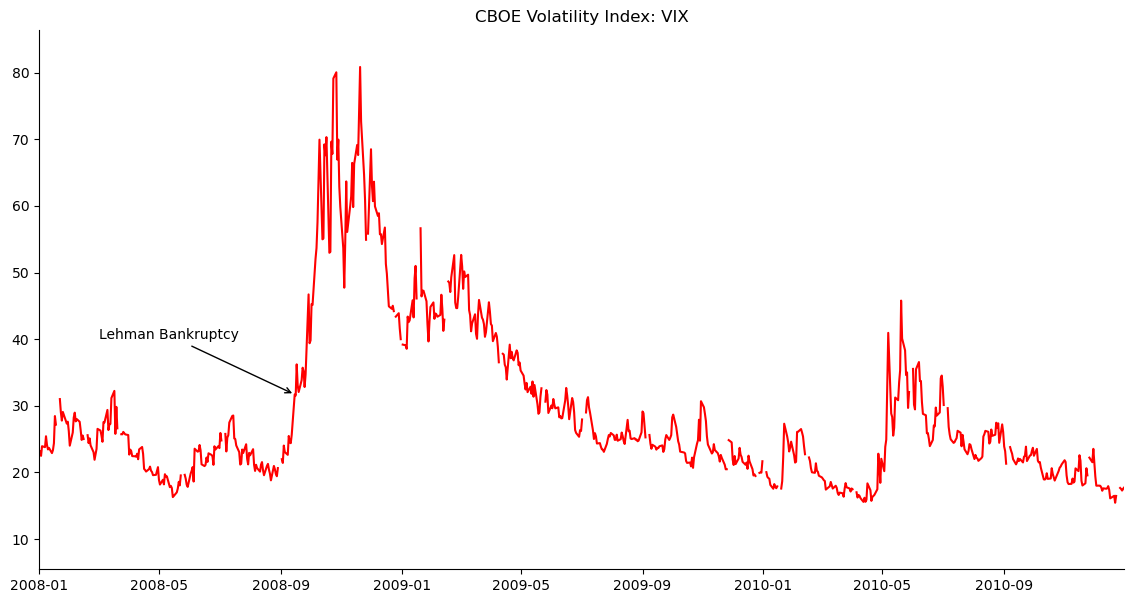

In [18]:
fig, ax = plt.subplots(figsize=(14,7))

ax.plot(vix.index, vix['VIXCLS'], color = 'red')

ax.set_title('CBOE Volatility Index: VIX')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Change the x-axis limits to focus around the Great Recession period. 
# The since the x-axis are dates, the limits are datetime objects.
ax.set_xlim(dt.datetime(2008,1,1), dt.datetime(2010, 12, 31)) 

# Add some annotations. The x-coordinate needs to be a datetime object.
#ax.axvline(dt.datetime(2008,9,15), color='black')
ax.annotate('Lehman Bankruptcy', 
            xy=(dt.datetime(2008,9,15), 31.7), 
            xytext=(dt.datetime(2008,3,1), 40), 
            arrowprops={'facecolor':'black',  'arrowstyle':'->'}
           ) 

plt.show()

## Practice: Dates
Take a few minutes and try the following. Feel free to chat with those around if you get stuck.

1. Read the file 'osk.csv' into a DataFrame and name it "prices". The file contains daily closing prices for OshKosh Corp. and the S&P500. 
2. Set the index to the date. Make sure the dates are datetime objects!


In [36]:
prices = pd.read_csv('data/osk.csv', parse_dates=['Date'], index_col='Date')
prices.head()

,sp500,osk
Date,,
2017-10-24,2569.13,89.680000
2017-10-25,2557.15,89.180000
2017-10-26,2560.40,90.610001
2017-10-27,2581.07,91.019997
2017-10-30,2572.83,89.570000


3. *Normalize* each series (osk, sp500) by dividing every observation by the value at 01-02-2018. Try 
```python
prices['osk_n'] = prices['osk'] / prices.loc['2018-01-02','osk']
```
and something similar for the S&P500.


In [39]:
prices['sp500_n'] = prices['sp500'] / prices.loc['2018-01-02', 'sp500']

4. Plot the two normalized series. What does normalizing do for us? \[Try plotting the non-normalized data. Can you see why we normalized?\]

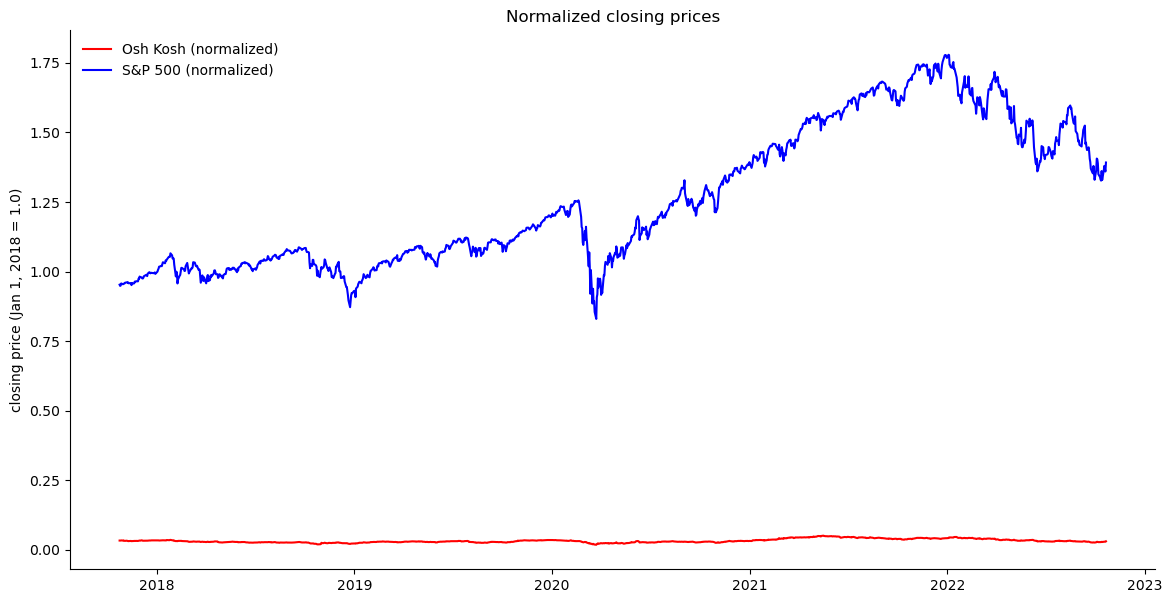

In [43]:
fig, ax = plt.subplots(figsize=(14,7))
ax.plot(prices.index, prices['osk_n'], color='red', label='Osh Kosh (normalized)')
ax.plot(prices.index, prices['sp500_n'], color='blue', label='S&P 500 (normalized)')

ax.set_ylabel('closing price (Jan 1, 2018 = 1.0)')
ax.set_title('Normalized closing prices')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False)

plt.show()

### Changing the frequency
We can *resample* the data to change its frequency. 

We are *downsampling* data if we are reducing the number of observations (daily$\rightarrow$monthly) and we are *upsampling* the data if we are increasing the number of observations (monthly$\rightarrow$daily). In my work, I have downsampled a lot. I do not think I have ever upsampled. 

* When we downsample, we need to tell pandas how we want the data aggregated: for example, we might want it summed, or averaged.

* When we resample, we create a new DataFrame to hold the new data. The index in the new data will be of a different frequency than the old data, so it is easiest to have different DataFrames. 

Let's resample to the weekly frequency and take the average over the observations within a week.

In [44]:
# Create a new DataFrame with a weekly index. 
vix_w = vix.resample('W-MON').mean()

print(vix_w.index)
print('\n', vix_w.head())

DatetimeIndex(['1990-01-08', '1990-01-15', '1990-01-22', '1990-01-29',
               '1990-02-05', '1990-02-12', '1990-02-19', '1990-02-26',
               '1990-03-05', '1990-03-12',
               ...
               '2022-08-22', '2022-08-29', '2022-09-05', '2022-09-12',
               '2022-09-19', '2022-09-26', '2022-10-03', '2022-10-10',
               '2022-10-17', '2022-10-24'],
              dtype='datetime64[ns]', name='DATE', length=1712, freq='W-MON')

             VIXCLS
DATE              
1990-01-08  19.004
1990-01-15  23.134
1990-01-22  24.376
1990-01-29  25.692
1990-02-05  25.268


We had 8,559 daily observations. Now we have 1,712 weekly observations.  Note the weeks are Sunday-based (`W-SUN`). Let's downsample some more. 

In [21]:
vix_m = vix_di.resample('ME').mean()   # monthly
vix_y = vix_di.resample('YE').mean()   # yearly

vix_y.head()

,VIXCLS
DATE,
1990-12-31,23.063478
1991-12-31,18.373373
1992-12-31,15.452047
1993-12-31,12.686245
1994-12-31,13.925516


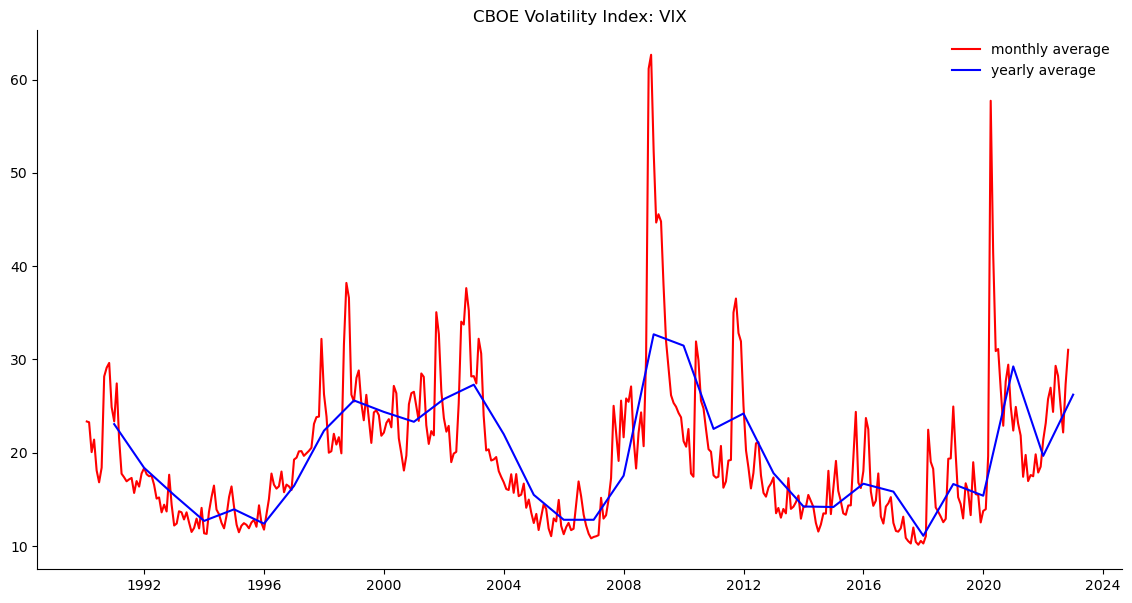

In [22]:
fig, ax = plt.subplots(figsize=(14,7))

ax.plot(vix_m.index, vix_m['VIXCLS'], color = 'red', label = 'monthly average')
ax.plot(vix_y.index, vix_y['VIXCLS'], color = 'blue', label = 'yearly average')

ax.set_title('CBOE Volatility Index: VIX')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False)

plt.show()

Notice that plotting at different frequencies was handled without a problem. Matplotlib/Pandas is handling all the datetime manipulation for us. 

### Slicing with dates
We can also slice on a datetime index. This is surprisingly easy. 

1. A single slice of data: 6/18/2008.

In [23]:
# You can input a datetime object or query directly with a string
vix.loc['2008/06/18']

VIXCLS    22.24
Name: 2008-06-18 00:00:00, dtype: float64

2. Grab every observation with a year of 2008.

In [24]:
print('Every week in 2008:\n\n', vix_w.loc['2008'])  # all the weeks in 2008

Every week in 2008:

              VIXCLS
DATE               
2008-01-07  23.3475
2008-01-14  23.9160
2008-01-21  25.8400
2008-01-28  28.9340
2008-02-04  26.2300
2008-02-11  28.0960
2008-02-18  25.4425
2008-02-25  24.4400
2008-03-03  24.1880
2008-03-10  26.9080
2008-03-17  28.8540
2008-03-24  26.9950
2008-03-31  25.8000
2008-04-07  22.8380
2008-04-14  22.8860
2008-04-21  20.8620
2008-04-28  20.0840
2008-05-05  19.3980
2008-05-12  18.9080
2008-05-19  17.0840
2008-05-26  18.4425
2008-06-02  18.9020
2008-06-09  21.2700
2008-06-16  22.5600
2008-06-23  22.0920
2008-06-30  22.9760
2008-07-07  25.0375
2008-07-14  25.9880
2008-07-21  25.1500
2008-07-28  22.6140
2008-08-04  22.4480
2008-08-11  20.6600
2008-08-18  20.7240
2008-08-25  20.2600
2008-09-01  20.0825
2008-09-08  22.6300
2008-09-15  26.3480
2008-09-22  33.3560
2008-09-29  37.0380
2008-10-06  44.3300
2008-10-13  60.0140
2008-10-20  63.0580
2008-10-27  69.9500
2008-11-03  62.6780
2008-11-10  56.4100
2008-11-17  64.6380
2008-11-24  72.026

3. Grab every observation between Jan 1, 2008 and Jan 31, 2008 by slicing with '2008/01/01':'2008/01/31'. Python is smart enough to understand references to dates that are not in the DataFrame. There is no January 1 or January 31 observation.

In [25]:
print('Every week in Jan 2008:\n\n', vix_w.loc['2008/01/01':'2008/01/31']) 
# Alternative
#print('Every week in Jan 2008:\n\n', vix_w.loc['2008-01'])  

Every week in Jan 2008:

              VIXCLS
DATE               
2008-01-07  23.3475
2008-01-14  23.9160
2008-01-21  25.8400
2008-01-28  28.9340


### Moving averages

We can also calculate moving averages of time series with `.rolling()`. For example, we can take a moving average of the monthly data over the year. Let's specify `window=12` to create a moving average over 12 months, and `center=True` to center the averaging window around each month.

In [26]:
vix_mov = vix_m.rolling(window=12, center=True).mean() # moving average per year

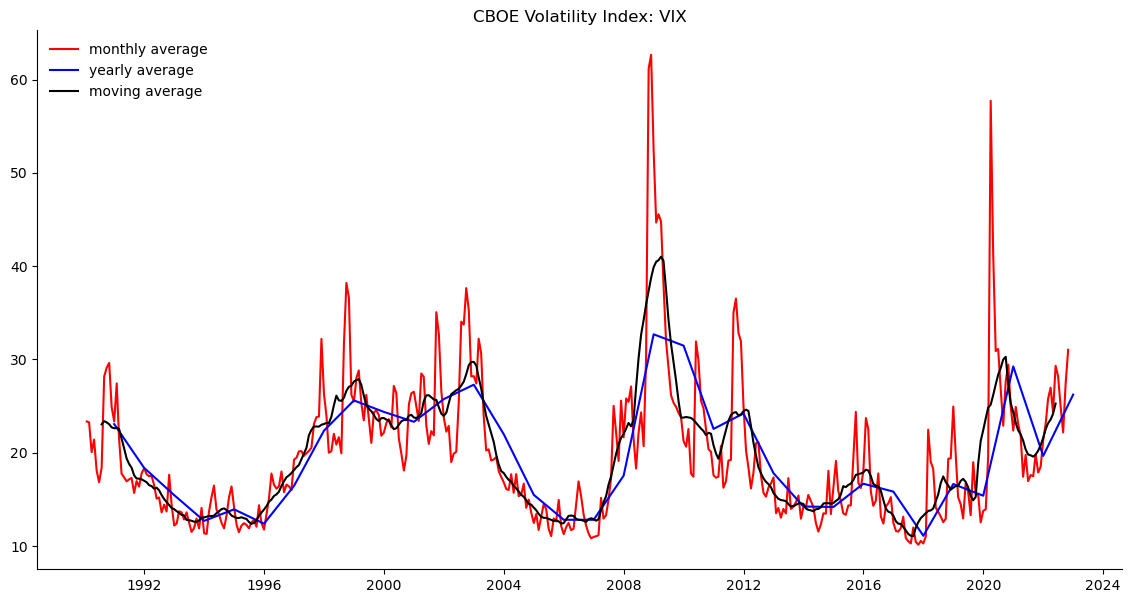

In [27]:
fig, ax = plt.subplots(figsize=(14,7))

ax.plot(vix_m.index, vix_m['VIXCLS'], color = 'red', label = 'monthly average')
ax.plot(vix_y.index, vix_y['VIXCLS'], color = 'blue', label = 'yearly average')
ax.plot(vix_mov.index, vix_mov['VIXCLS'], color = 'black', label = 'moving average')

ax.set_title('CBOE Volatility Index: VIX')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False)

plt.show()

Note that the moving average (black) is similar to the yearly average (blue), but moves more frequently with each change in the month. This is a great way to smooth out short-term volatility and identify trends in the data without sacrificing frequency of the data through downsampling.

## Try at Home

Continuing work with the `prices` DataFrame you created earlier. It containes the normalized prices of OshKosh and the SP500.


If you didn't finish the last practice, run this code to create the daily data:

```python
prices = pd.read_csv('osk.csv', parse_dates=['Date'], index_col='Date')
prices['osk_n'] = prices['osk'] / prices.loc['2018-01-02','osk']
prices['sp500_n'] = prices['sp500'] / prices.loc['2018-01-02','sp500']

```

In [28]:
prices = pd.read_csv('data/osk.csv', parse_dates=['Date'], index_col='Date')
prices['osk_n'] = prices['osk'] / prices.loc['2018-01-02','osk']
prices['sp500_n'] = prices['sp500'] / prices.loc['2018-01-02','sp500']

1. Use the normalized data to take a moving average over the course 60 days (not including weekends).

2. Add the moving average data to your figure from part 4. Use the `alpha` option to lighten up the daily data lines.
3. How does your plot look? Use `ax.set_xlim()` to choose a more appropriate time period for comparison of moving averages and the daily data.
4. Are the titles correct? Is there a legend or some other way of identifying the lines?

#### A note about centering moving averages

If we redo the exercise calculating the moving averages with `center=False`, the moving averages will actually *lag* the daily data. This phenomenon is sometimes referred to as *hysteresis*.

In this case, the *centered* moving average seems to track the underlying data pattern. What does the uncentered moving average look like? 

More generally, pay attention to where your downsampled or averaged data is *anchored*.

In [29]:
prices['osk_mov2'] = prices['osk_n'].rolling(window=60, center=False).mean() 
prices['sp500_mov2'] = prices['sp500_n'].rolling(window=60, center=False).mean() 
prices

,sp500,osk,osk_n,sp500_n,osk_mov2,sp500_mov2
Date,,,,,,
2017-10-24,2569.13,89.680000,0.972985,0.953009,NaN,NaN
2017-10-25,2557.15,89.180000,0.967560,0.948565,NaN,NaN
2017-10-26,2560.40,90.610001,0.983075,0.949770,NaN,NaN
2017-10-27,2581.07,91.019997,0.987523,0.957438,NaN,NaN
2017-10-30,2572.83,89.570000,0.971791,0.954381,NaN,NaN
...,...,...,...,...,...,...
2022-10-17,3677.95,77.809998,0.844201,1.364321,0.869677,1.465040
2022-10-18,3719.98,79.500000,0.862537,1.379912,0.868280,1.463513
2022-10-19,3695.16,79.209999,0.859390,1.370705,0.867037,1.462117


In [30]:
print('min of osk_mov2:',prices.loc[~prices['osk_mov2'].isna()].index.min())
print('max of osk_mov2:',prices.loc[~prices['osk_mov2'].isna()].index.max())

min of osk_mov2: 2018-01-19 00:00:00
max of osk_mov2: 2022-10-21 00:00:00


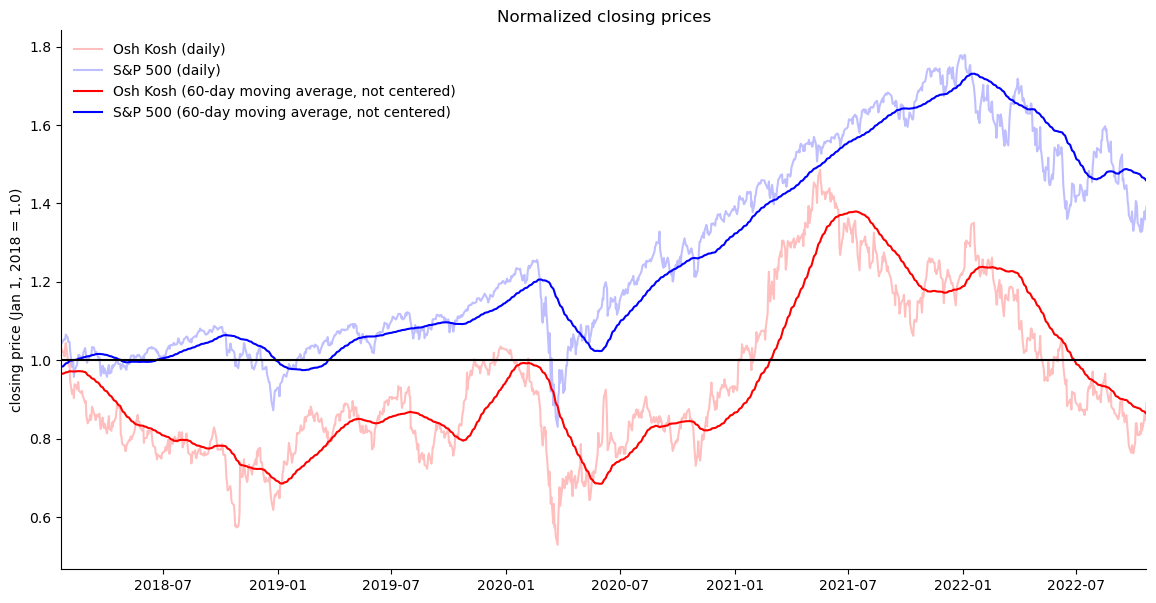

In [31]:
fig, ax = plt.subplots(figsize=(14,7))
ax.plot(prices.index, prices['osk_n'], color = 'red', label = 'Osh Kosh (daily)', alpha = 0.25)
ax.plot(prices.index, prices['sp500_n'], color = 'blue', label = 'S&P 500 (daily)', alpha = 0.25)

ax.plot(prices.index, prices['osk_mov2'], color = 'red', label = 'Osh Kosh (60-day moving average, not centered)')
ax.plot(prices.index, prices['sp500_mov2'], color = 'blue', label = 'S&P 500 (60-day moving average, not centered)')

ax.set_xlim( dt.datetime(2018,1,19), dt.datetime(2022, 10, 21) ) # The limits need datetime objects
ax.set_ylabel('closing price (Jan 1, 2018 = 1.0)')
ax.set_title('Normalized closing prices')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axhline(y=1, color='black')

ax.legend(frameon=False)

plt.show()